Found 0 images belonging to 12 classes.


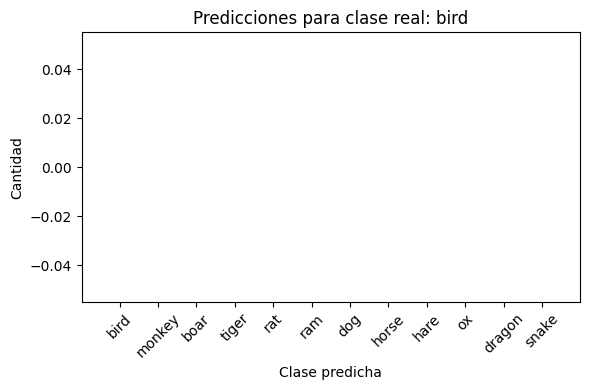

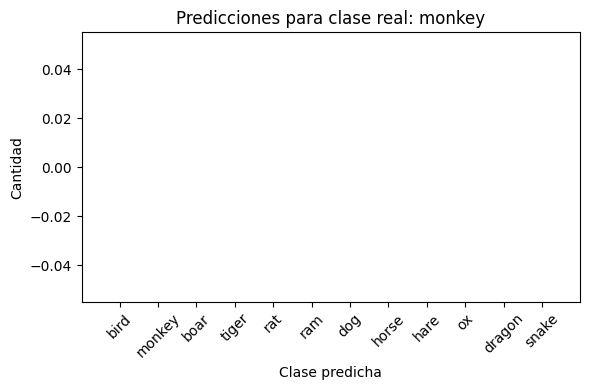

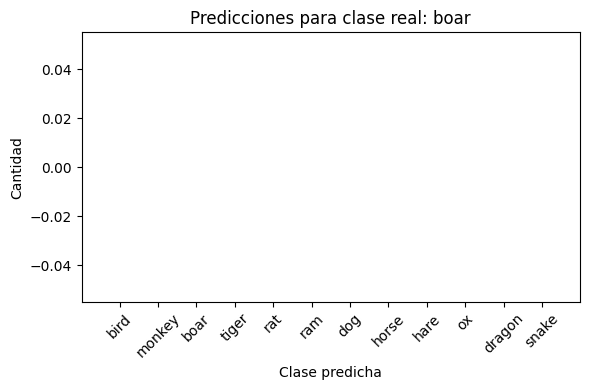

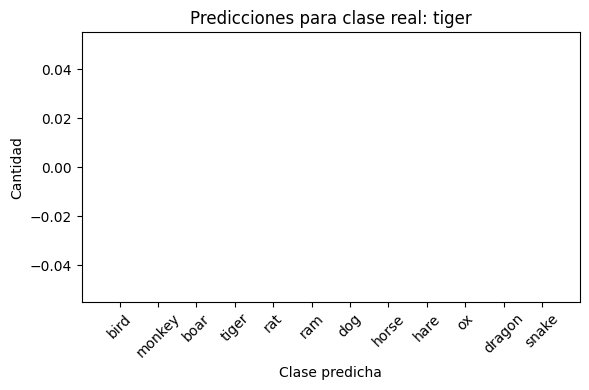

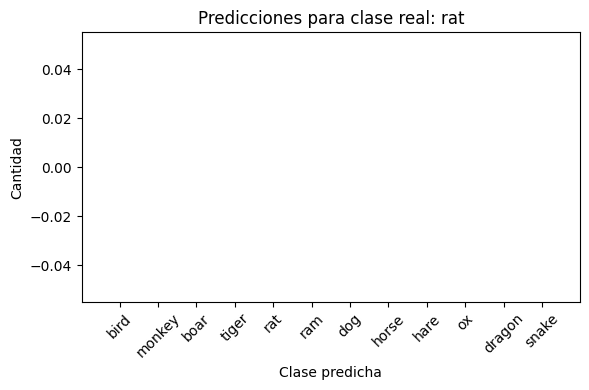

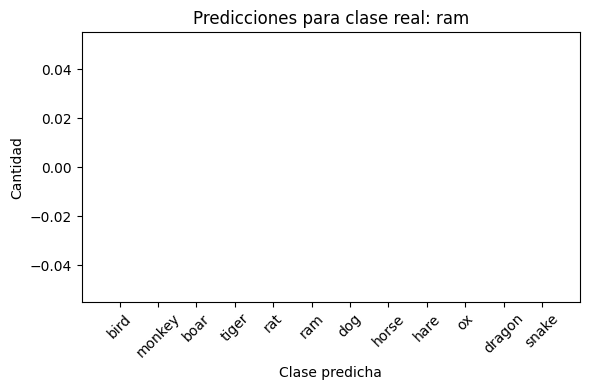

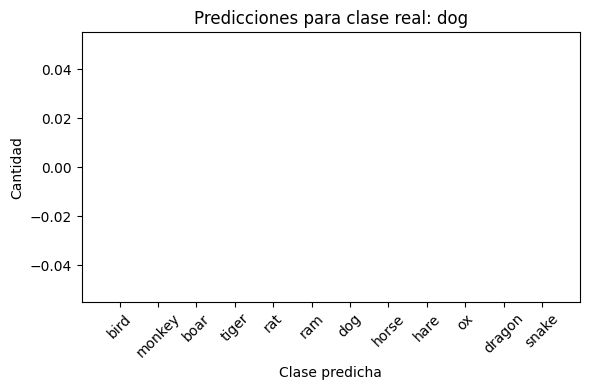

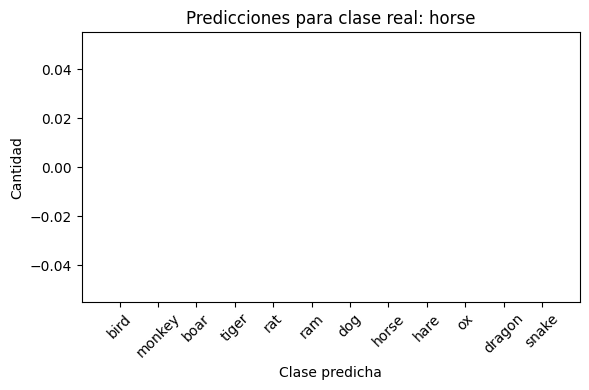

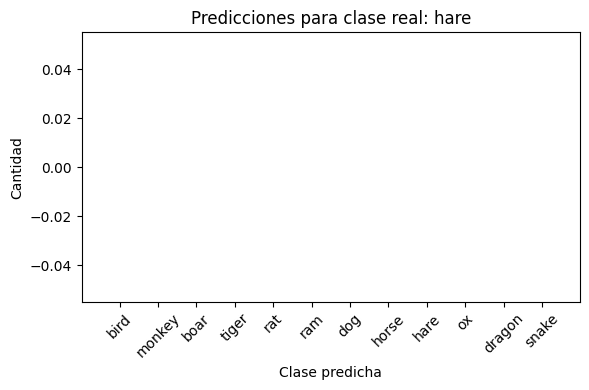

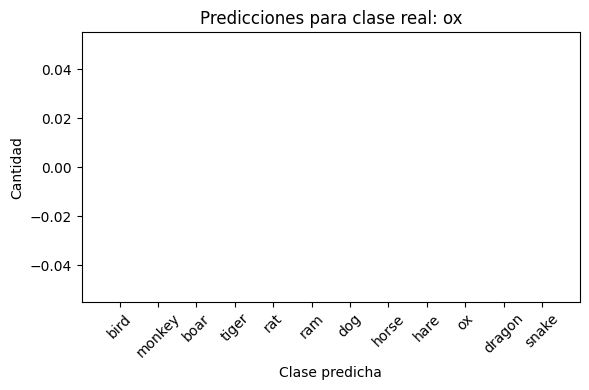

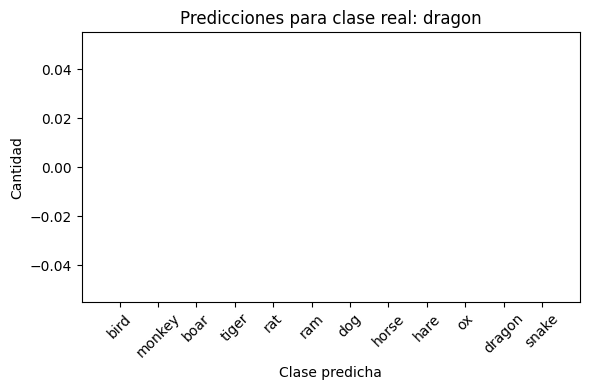

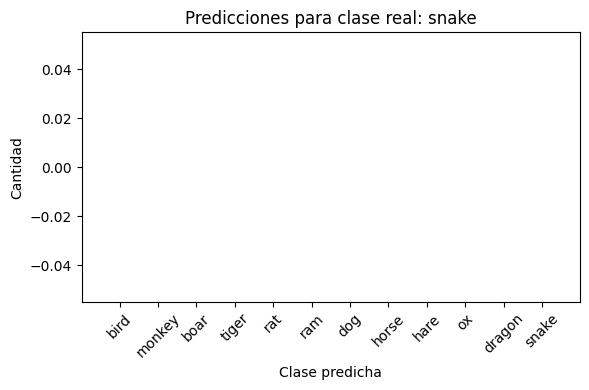

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

# Cargar modelo
model_name = "clasificador_narutox.keras"
model = tf.keras.models.load_model(model_name)


# Probar el modelo con el dataset, graficar para cada clase la cantidad de aciertos y errores
import matplotlib.pyplot as plt
import numpy as np

used_classes = ['bird', 'monkey', 'boar', 'tiger', 'rat', 'ram', 'dog', 'horse', 'hare', 'ox', 'dragon', 'snake']


# Cargar dataset
dataset_path = 'dataset/train'
IMAGE_SIZE = 300
dataset = ImageDataGenerator()

dataset = dataset.flow_from_directory(
    dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=10,
    classes=used_classes,
    class_mode='categorical',
)

# Obtener nombres de clases y número de clases
class_indices = dataset.class_indices
class_names = list(class_indices.keys())
num_classes = len(class_names)

# Obtener todas las imágenes y etiquetas verdaderas del test set
dataset.reset()
y_true = []
y_pred = []

for i in range(len(dataset)):
    x_batch, y_batch = dataset[i]
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Graficar un histograma por clase real, cada uno en una figura separada
for idx, class_name in enumerate(class_names):
    mask = y_true == idx
    pred_for_class = y_pred[mask]
    plt.figure(figsize=(6, 4))
    plt.hist(pred_for_class, bins=np.arange(num_classes+1)-0.5, rwidth=0.8, align='mid')
    plt.xticks(range(num_classes), class_names, rotation=45)
    plt.title(f'Predicciones para clase real: {class_name}')
    plt.xlabel('Clase predicha')
    plt.ylabel('Cantidad')
    plt.tight_layout()
    plt.show()

